In [90]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import sqlite3

In [91]:
# data importing 
conn = sqlite3.connect('customer_Churn.db')
sql_querry = """
    Select name 
    from sqlite_master
    where type = 'table'
"""

tables = pd.read_sql(sql_querry, conn)


# create dataframe for each table 

for table_name in tables['name']:
    df = pd.read_sql(f'select * from {table_name}' , conn)
    globals()[f"df_{table_name}"] = df
    print(f"created dataframe: df_{table_name}")

conn.close()

created dataframe: df_db_customer
created dataframe: df_db_subscription
created dataframe: df_db_support


# data cleaning

In [92]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [93]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [94]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [95]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [96]:
# table 1 
# rename col = name
# change data type of dob column
# drop interest and pincode column 
# fix missing values in country
# fix isssue in gender columns 

In [97]:
# renaming col 
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)


In [98]:
# drop columns 
# df_db_customer.drop(df_db_customer.columns[-2:], axis = 1) --> it is using index value 

df_db_customer.drop(columns=['interests','pincode'] , inplace = True)

In [99]:
#  changing data types 
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [100]:
# data standardization 
# df_db_customer['gender'].unique()

df_db_customer['gender']=df_db_customer['gender'].replace({'Men' : 'Male' , 'Women' :'Female'} )

In [101]:
# fixing the mixing the missing data
# df_db_customer.isnull().sum()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [102]:
# country and state - unique value pair

state_country_mapping=df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))



In [103]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [104]:
# now it is filled with corr3ect data
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [105]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaN,NaN,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaN,NaN,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaN,NaN,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaN,NaN,6.99,335,41


In [106]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [107]:
# date column 

date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


In [108]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [109]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [110]:
# dropping the two unused columns
df_db_support.drop(columns = ['col_1', 'comment'],inplace = True)

In [111]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30


In [112]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerid      9 non-null      str  
 1   complaint_date  9 non-null      str  
 2   escalations     9 non-null      str  
 3   csat_score      9 non-null      int64
dtypes: int64(1), str(3)
memory usage: 690.0 bytes


In [113]:
# chnaging the date time data types 
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [114]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 519.0 bytes


# Feature Engineering 

In [115]:
# creating a new column for the churn_score column to keep track which customer has churn and which has not 
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [116]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [117]:
# joining all 3 tables into one using the merge command on customerid

df = (df_db_subscription
                .merge(df_db_customer, on = 'customerid', how= 'left')
                .merge(df_db_support, on = 'customerid', how= 'left'))

In [118]:
df.shape

(23, 20)

In [119]:
df_db_subscription.shape

(21, 12)

In [120]:
df_db_subscription['customerid'].nunique()

21

In [121]:
df_db_customer['customerid'].nunique()

21

In [122]:
df_db_support['customerid'].nunique()

7

In [123]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [124]:
df_db_support['complain_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [125]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complain_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [126]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep = 'last')

In [127]:
# final merge after solving support table issue 
df = (df_db_subscription
                .merge(df_db_customer, on = 'customerid', how= 'left')
                .merge(df_db_support, on = 'customerid', how= 'left'))

In [128]:
df.shape

(21, 21)

In [129]:
df.to_csv('exported_churn_Data.csv', index = False)

# Data Analysis

In [130]:
# churn rate


In [131]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='str')

In [132]:
# churn rate 
churn_rate=df['churn_flag'].mean()*100

print("Churn rate=" , round(churn_rate,2),"%")

Churn rate= 28.57 %


In [133]:
# retention rate
retention_rate = 100 - churn_rate
print("retention_rate=",round(retention_rate),"%")

retention_rate= 71 %


In [134]:
# churn by plan type 
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))

print(churn_by_plan) 
# max churn rate is from basic 

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [135]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count'],
      dtype='str')

In [136]:
# churn by state + sum of revenue and count of users 
churn_by_state=df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')

print(churn_by_state)

           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           50.00
8  Uttar Pradesh            0.00


In [137]:
#  churn by subscription type + sum of revenue and count of users 

churn_by_subscription_type = df.groupby('subscription_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct')
print(churn_by_subscription_type)

  subscription_type  churn_rate_pct
0           Organic            0.00
1              Paid           16.67
2          Refferal           83.33


In [138]:
# ARPU :- AVG REVENUE PER USER 

arpu = df['monthly_charges'].mean()
print('ARPU = ' , round(arpu,2))

ARPU =  18.85


In [139]:
# avg tenure of user with us column are 'subscription_start_date'  or 'cancellation_date'
# count od days user has used our service : cancellation date else current date 

# current date 
currdate = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

    (df['cancellation_date']-df['subscription_start_date']).dt.days,

    (currdate - df['subscription_start_date']).dt.days
)


avg_tenure = df['tenure_days'].mean()
print("avg tenure days = " , round(avg_tenure,0))

avg tenure days =  1533.0


In [140]:
# revenue at risk - revenue lost from churned user

revenue_at_risk = df.loc[df['churn_flag']==1 , 'monthly_charges'].sum()
print("revenue at risk (rs 'k' ) =", revenue_at_risk )

revenue at risk (rs 'k' ) = 73.94


In [141]:
# esclation rate 
escalation_rate = (df['escalations']=='Y').mean()*100
print(escalation_rate)

19.047619047619047


In [142]:
# avg complaint rate per user
avg_complaints = df['complain_count'].sum() / df['customerid'].nunique()
print("avg complaint per user= " , round(avg_complaints,2))

avg complaint per user=  0.43


In [143]:
# correlation escalation vs churn 

# df['escalations'] = np.where(df['escalations']=='Y',1,0) #encoding str to int type
corr_df = df[['escalations','churn_flag']].dropna()

corr_df['escalations'].corr(df['churn_flag'])
print(correlation)

ValueError: could not convert string to float: 'Y'

In [144]:
# churn risk - create a column using existing columns 

conditions = [

    (df['churn_score']<50),
    (df['churn_score']>= 50) & (df['churn_score']<70),
    (df['churn_score']>= 70)
]

choices = ['low' , 'mid' , 'high']

df['churn_risk'] = np.select(conditions , choices , default = 'unknown')

# Data Visualization

In [145]:
df_visual=df.copy()

In [146]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

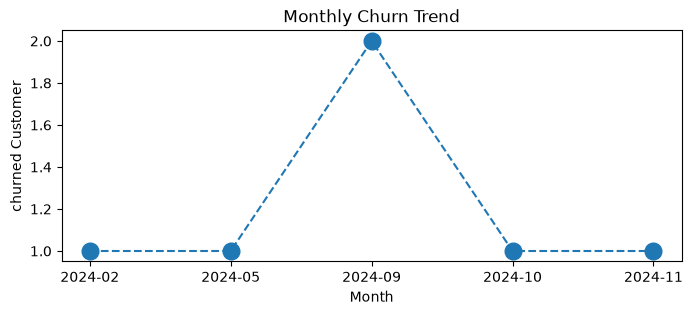

In [147]:
# monthly churn trend chart[time series KPI]

df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')
churn_trend= df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()

plt.figure(figsize = (8,3))
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('churned Customer')
plt.plot(churn_trend.index.astype(str),churn_trend.values,marker='o',markersize = 12,linestyle='dashed')
plt.show()

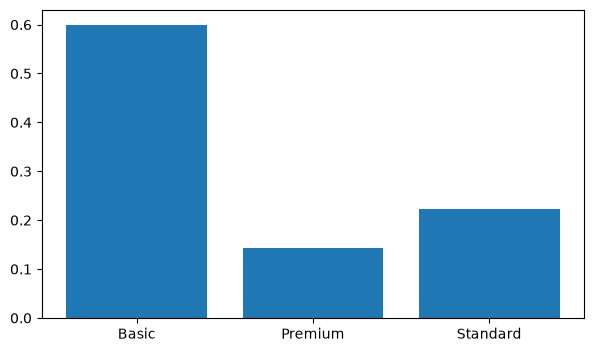

In [148]:
# 2 churn by plantype
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()

# color = ['yellow','green','red']
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

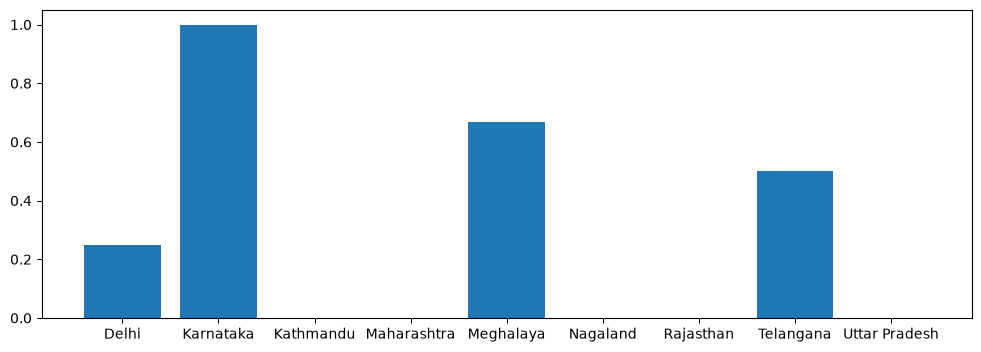

In [149]:
# churn by states
# 2 churn by plantype
churn_plan=df_visual.groupby('state')['churn_flag'].mean()

# color = ['yellow','green','red']
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index,churn_plan.values)
plt.show()

<Axes: >

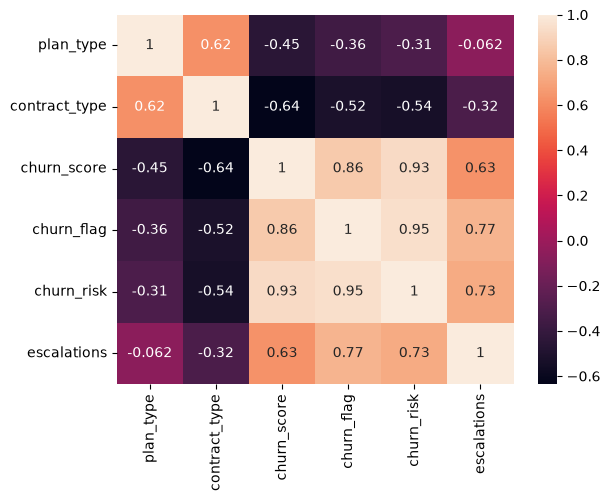

In [165]:
# Select columns
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].copy()

# Ordinal encoding
order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'mid', 'high']
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col], categories=order, ordered=True).codes

# Map Y -> 1, N/NaN -> 0 and force integer type
df_encoded['escalations'] = df_encoded['escalations'].replace({'Y': 1, 'N': 0}).fillna(0).astype(int)

# Heatmap
sns.heatmap(df_encoded.corr(), annot=True)

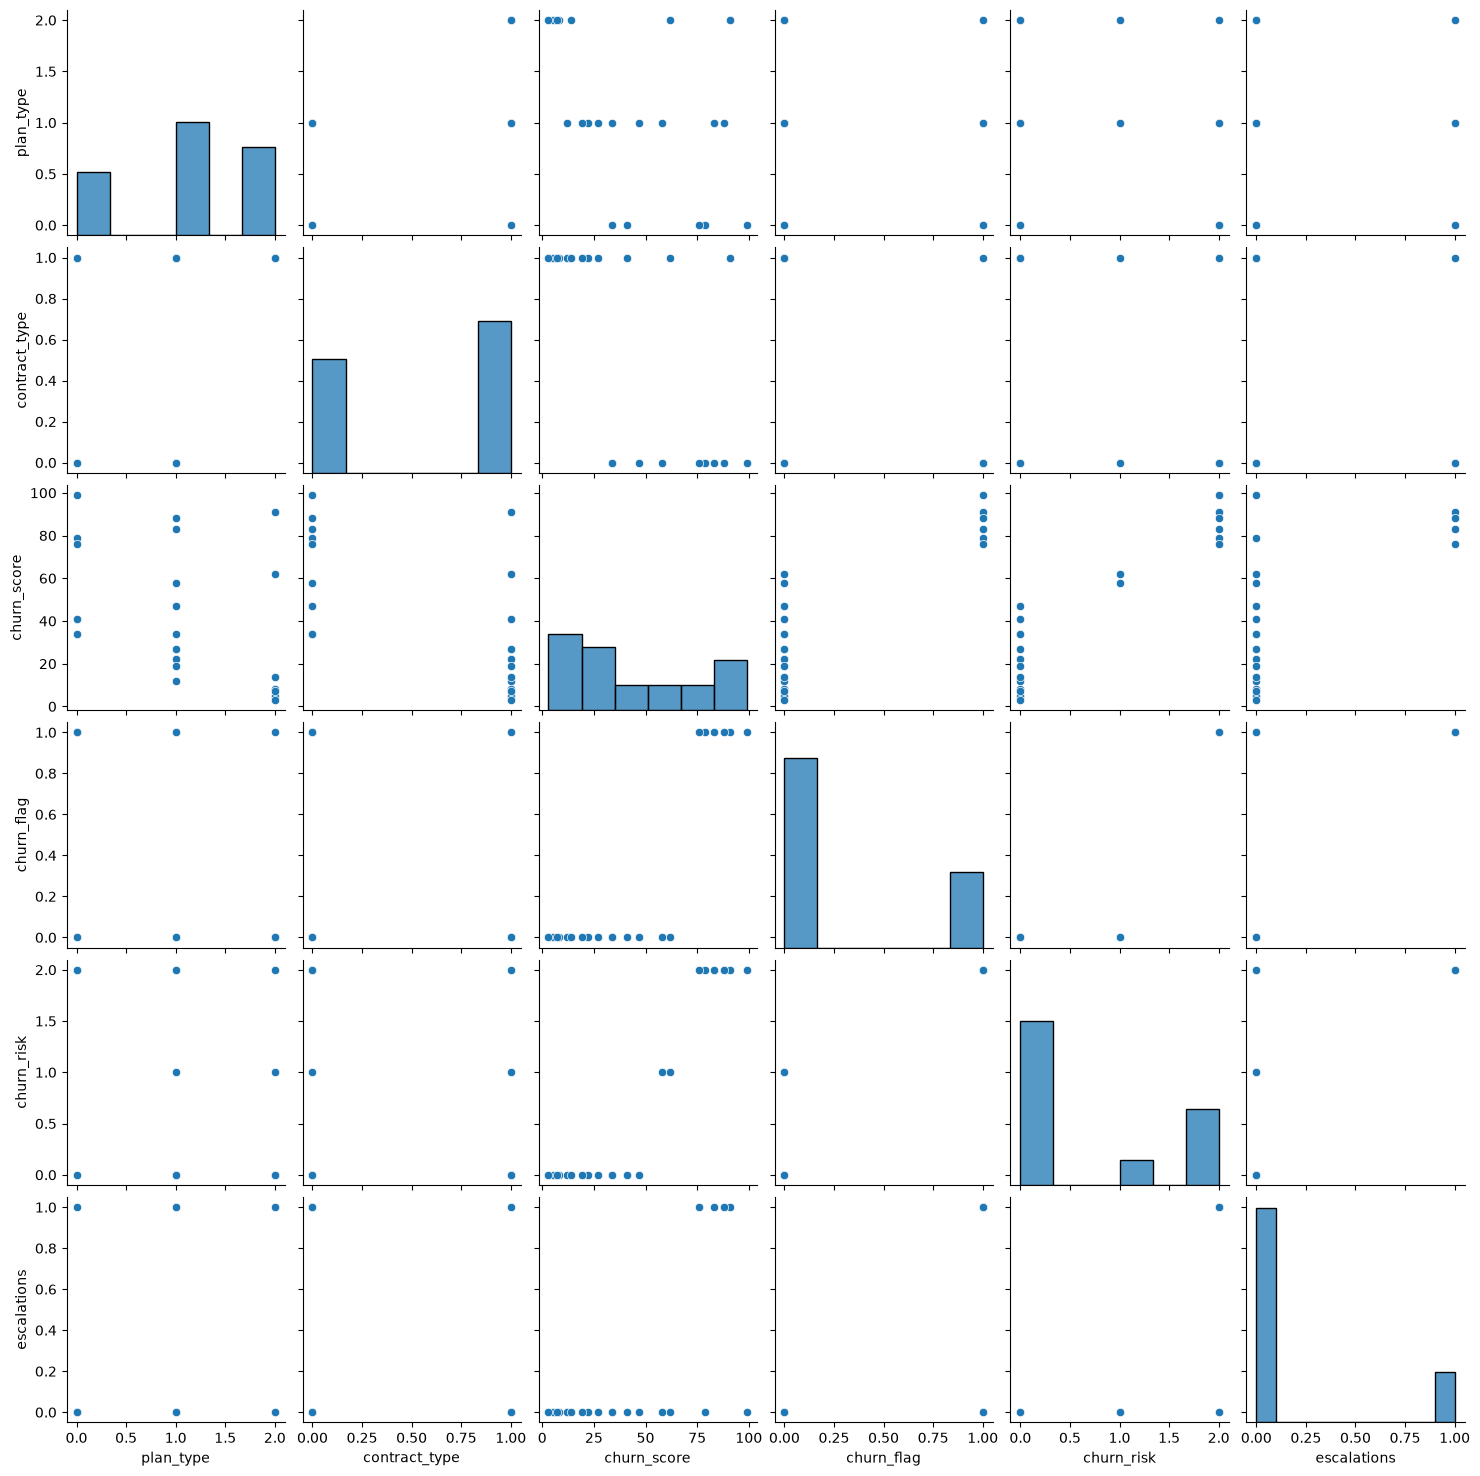

In [167]:
# pair plot : relationship in dataset
sns.pairplot(df_encoded)

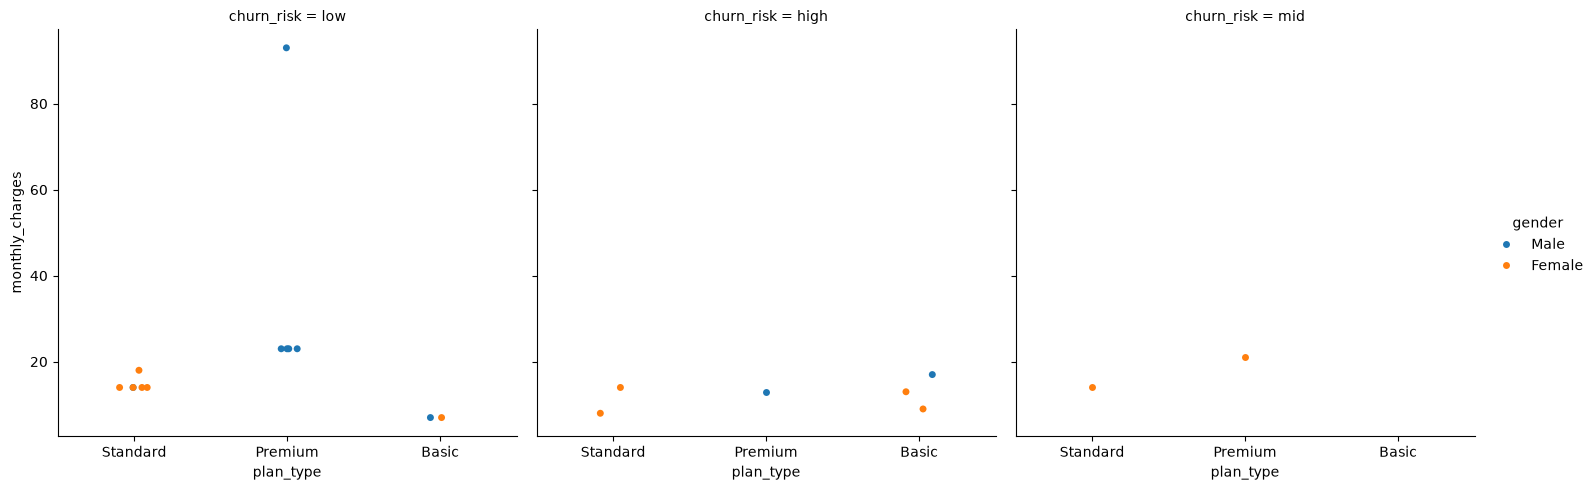

In [172]:
# facegrid plot/ cat plot ---> multidimension comparision

sns.catplot(
    data= df_visual,
    x = 'plan_type',
    y = 'monthly_charges',
    hue = 'gender',
    col = 'churn_risk'
)

# Pivot Table

In [174]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [176]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['churn_flag','monthly_charges','customerid'],
    
    aggfunc = {
        'churn_flag' : 'mean',
        'monthly_charges' : 'sum',
        'customerid': 'nunique'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [180]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complain_count',
       'tenure_days'],
      dtype='str')

In [188]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complain_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1995.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0,high
